In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
mutual_reg = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/df_rows_0_0_0_13122025_041427_ncells_6000_Mutual_regulation_additive_0_0_8c11d69c.csv")
fan_out = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/df_rows_0_0_0_13122025_031632_ncells_6000_Fan_out_additive_2_0_c69c7586.csv")
fan_in = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/fan_in/df_rows_0_0_0_18022026_125815_ncells_6000_fan_in_k_add_6_13_0_c858ec07.csv")
feed_forward = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/feed_forward/df_rows_0_0_0_17022026_160709_ncells_6000_feed_forward_k_add_6_10_0_b2eea22c.csv")
a_to_b = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/A_to_B/df_rows_0_0_0_17022026_120324_ncells_6000_A_to_B_k_add_6_1_0_5d18a8ec.csv")
a_and_b = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/A_and_B/df_rows_0_0_0_17022026_160514_ncells_6000_A_and_B_k_add_6_4_0_58575e6d.csv")

In [52]:
mutual_reg_t1 = mutual_reg[mutual_reg['time_step'] ==1]
fan_out_t1 = fan_out[fan_out['time_step'] ==1]
fan_in_t1 = fan_in[fan_in['time_step'] ==1]
feed_forward_t1 = feed_forward[feed_forward['time_step'] ==1]
a_to_b_t1 = a_to_b[a_to_b['time_step'] == 1]
a_and_b_t1 = a_and_b[a_and_b['time_step'] == 1]

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_divergence(df, network, genes, n_random=2000, seed=0):

    rng = np.random.default_rng(seed)
    time_points = sorted(df["time_step"].unique())

    # Containers
    twin_median = {g: [] for g in genes}
    twin_q25 = {g: [] for g in genes}
    twin_q75 = {g: [] for g in genes}
    twin_p95 = {g: [] for g in genes}

    rand_median = {g: [] for g in genes}
    rand_q25 = {g: [] for g in genes}
    rand_q75 = {g: [] for g in genes}
    rand_p95 = {g: [] for g in genes}

    for t in time_points:

        df_t = df[df["time_step"] == t]
        df_sub = df_t[["clone_id"] + genes].copy()

        # -----------------------------
        # Twin differences
        # -----------------------------
        counts = df_sub["clone_id"].value_counts()
        valid_ids = counts[counts == 2].index
        twins = df_sub[df_sub["clone_id"].isin(valid_ids)]
        twins = twins.sort_values("clone_id")

        if len(twins) < 2:
            for g in genes:
                twin_median[g].append(np.nan)
                twin_q25[g].append(np.nan)
                twin_q75[g].append(np.nan)
                twin_p95[g].append(np.nan)
                rand_median[g].append(np.nan)
                rand_q25[g].append(np.nan)
                rand_q75[g].append(np.nan)
                rand_p95[g].append(np.nan)
            continue

        twin_array = twins[genes].to_numpy()
        twin_array = twin_array.reshape(-1, 2, len(genes))
        twin_diffs = np.abs(twin_array[:, 0, :] - twin_array[:, 1, :])

        # -----------------------------
        # Random differences
        # -----------------------------
        values = df_sub[genes].to_numpy()
        n_cells = values.shape[0]
        n_draw = min(n_random, n_cells // 2)

        idx1 = rng.choice(n_cells, n_draw, replace=False)
        idx2 = rng.choice(n_cells, n_draw, replace=False)

        random_diffs = np.abs(values[idx1] - values[idx2])

        # -----------------------------
        # Store statistics
        # -----------------------------
        for i, g in enumerate(genes):

            # Twin
            td = twin_diffs[:, i]
            twin_median[g].append(np.median(td))
            twin_q25[g].append(np.percentile(td, 25))
            twin_q75[g].append(np.percentile(td, 75))
            twin_p95[g].append(np.percentile(td, 95))

            # Random
            rd = random_diffs[:, i]
            rand_median[g].append(np.median(rd))
            rand_q25[g].append(np.percentile(rd, 25))
            rand_q75[g].append(np.percentile(rd, 75))
            rand_p95[g].append(np.percentile(rd, 95))

    # ====================================================
    # Plot
    # ====================================================
    fig, axes = plt.subplots(1, len(genes), figsize=(5*len(genes), 4), sharey=False)

    if len(genes) == 1:
        axes = [axes]

    for ax, g in zip(axes, genes):

        # Median
        ax.plot(time_points, twin_median[g], label="Twin Median")
        ax.plot(time_points, rand_median[g], label="Random Median")

        # IQR band
        ax.fill_between(time_points, twin_q25[g], twin_q75[g], alpha=0.2)
        ax.fill_between(time_points, rand_q25[g], rand_q75[g], alpha=0.2)

        # 95th percentile
        ax.plot(time_points, twin_p95[g], linestyle="--", label="Twin 95th")
        ax.plot(time_points, rand_p95[g], linestyle="--", label="Random 95th")

        ax.set_title(g)
        ax.set_xlabel("Time")
        ax.set_ylabel("Absolute Difference")
        # ax.set_ylim(0, 8)
    axes[0].legend()
    plt.axvline(1, label = "t = 1h")
    fig.suptitle(f"Divergence Over Time — {network}")
    plt.tight_layout()
    plt.show()


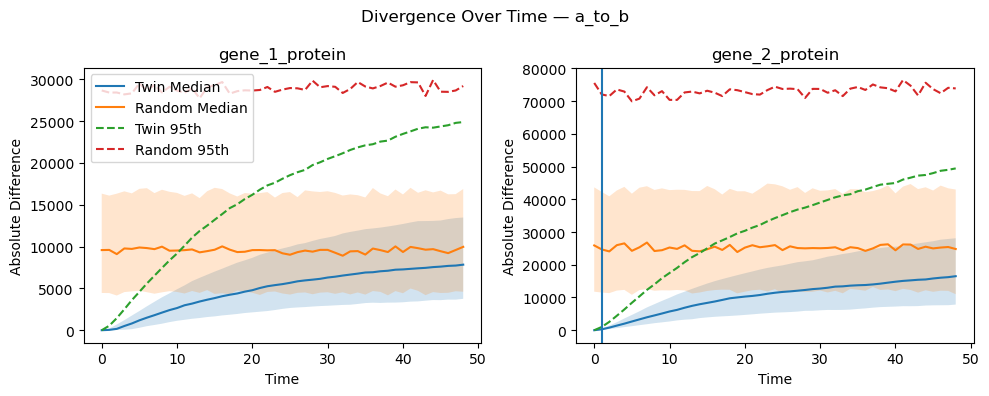

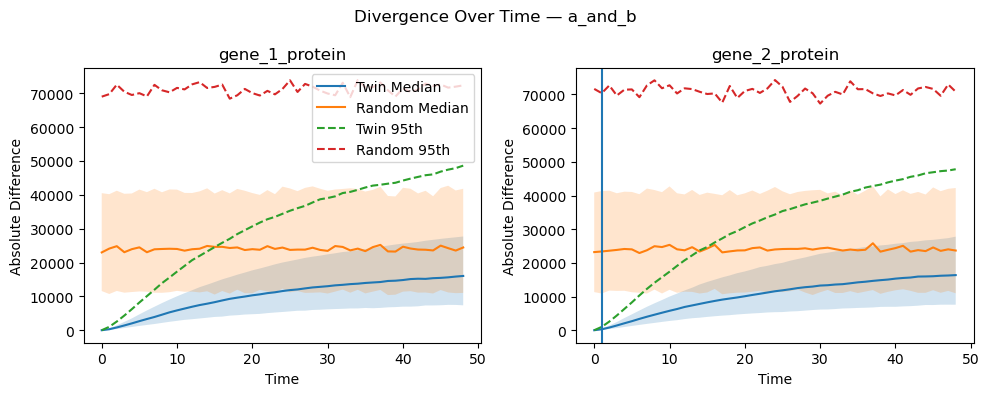

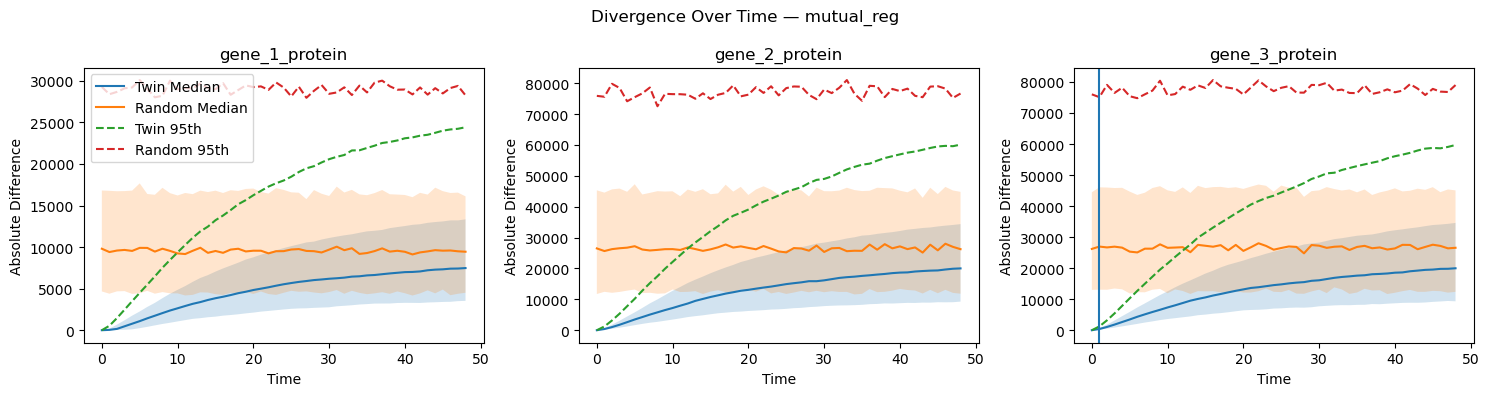

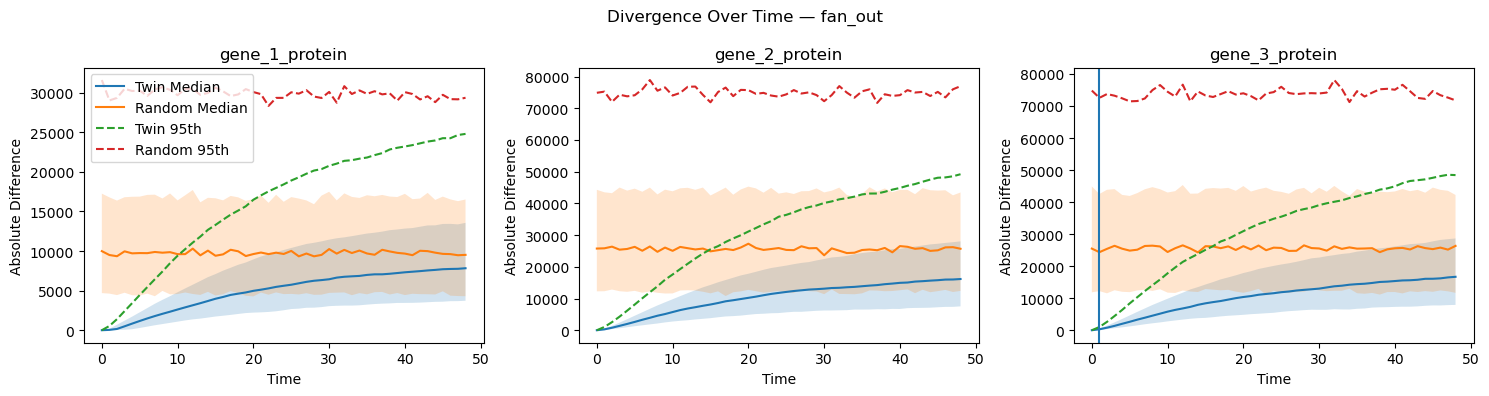

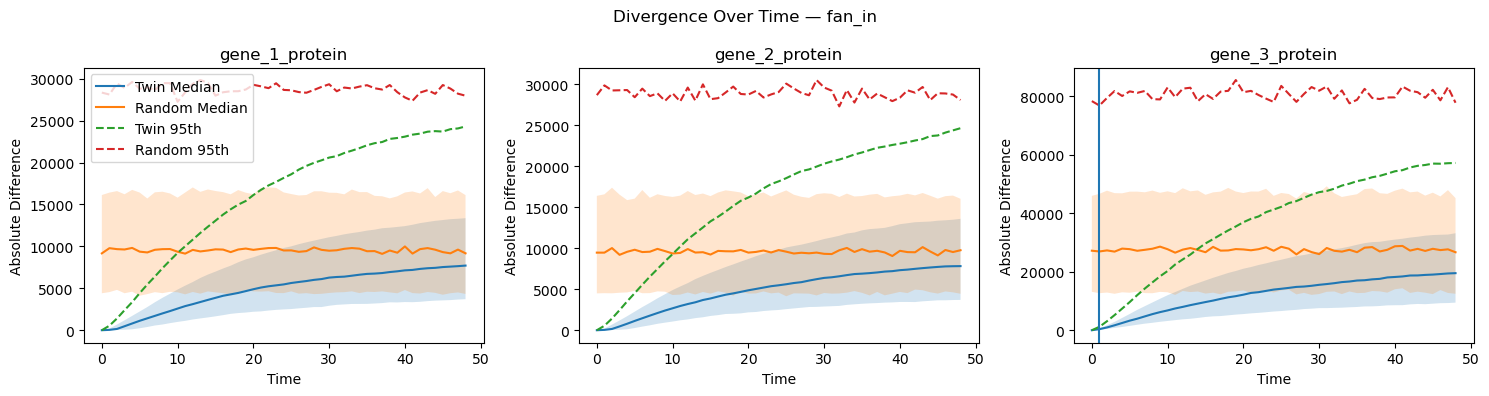

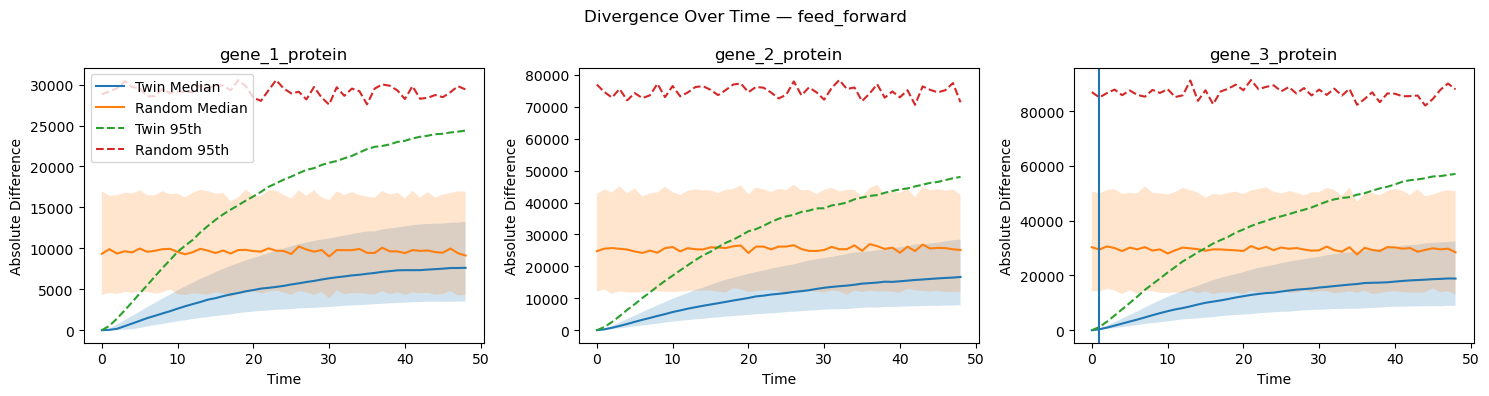

In [55]:
plot_divergence(a_to_b, "a_to_b", genes_2)
plot_divergence(a_and_b, "a_and_b", genes_2)
plot_divergence(mutual_reg, "mutual_reg", genes_3)
plot_divergence(fan_out, "fan_out", genes_3)
plot_divergence(fan_in, "fan_in", genes_3)
plot_divergence(feed_forward, "feed_forward", genes_3)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
    """
    Compute Cliff's delta effect size.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n_x = len(x)
    n_y = len(y)

    # Broadcasting comparison
    diff = x[:, None] - y[None, :]
    return (np.sum(diff > 0) - np.sum(diff < 0)) / (n_x * n_y)


def plot_gene_difference(df, network, genes, n_random=6000, seed=0):

    df_sub = df[["clone_id"] + genes].copy()

    # =========================
    # Twin differences
    # =========================
    counts = df_sub["clone_id"].value_counts()
    valid_ids = counts[counts == 2].index

    twins = df_sub[df_sub["clone_id"].isin(valid_ids)]
    twins = twins.sort_values("clone_id")

    twin_array = twins[genes].to_numpy()
    twin_array = twin_array.reshape(-1, 2, len(genes))
    twin_diffs = np.abs(twin_array[:, 0, :] - twin_array[:, 1, :])

    twin_df = pd.DataFrame(twin_diffs, columns=genes)
    twin_df["pair_type"] = "Twin"

    # =========================
    # Random differences
    # =========================
    rng = np.random.default_rng(seed)

    values = df_sub[genes].to_numpy()
    n_cells = values.shape[0]

    idx1 = rng.choice(n_cells, n_random, replace=False)
    idx2 = rng.choice(n_cells, n_random, replace=False)

    random_diffs = np.abs(values[idx1] - values[idx2])

    random_df = pd.DataFrame(random_diffs, columns=genes)
    random_df["pair_type"] = "Random"

    # =========================
    # Effect size calculation
    # =========================
    results = []

    for g in genes:
        twin_vals = twin_df[g].values
        rand_vals = random_df[g].values

        median_shift = np.median(rand_vals) - np.median(twin_vals)
        mean_ratio = np.mean(rand_vals) / (np.mean(twin_vals) + 1e-9)
        delta = cliffs_delta(rand_vals, twin_vals)
        stat, p = mannwhitneyu(rand_vals, twin_vals, alternative="two-sided")

        results.append({
            "Gene": g,
            "MedianShift(Random-Twin)": median_shift,
            "MeanRatio(Random/Twin)": mean_ratio,
            "CliffsDelta": delta,
            "MannWhitney_p": p
        })

    effect_df = pd.DataFrame(results)
    print(f"\nEffect Size Summary for {network}:")
    print(effect_df)

    # =========================
    # Plot
    # =========================
    plot_df = pd.concat([twin_df, random_df], ignore_index=True)

    plot_long = plot_df.melt(
        id_vars="pair_type",
        value_vars=genes,
        var_name="Gene",
        value_name="AbsDifference"
    )

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=plot_long,
        x="Gene",
        y="AbsDifference",
        hue="pair_type"
    )

    plt.ylabel("Absolute Difference")
    plt.title(f"Twin vs Random Pair Differences for network {network}")
    plt.tight_layout()
    plt.show()

    return 




Effect Size Summary for a_to_b:
          Gene  MedianShift(Random-Twin)  MeanRatio(Random/Twin)  CliffsDelta  \
0  gene_1_mRNA                       1.0                2.562526     0.385352   
1  gene_2_mRNA                       1.0                2.081437     0.407337   

   MannWhitney_p  
0            0.0  
1            0.0  


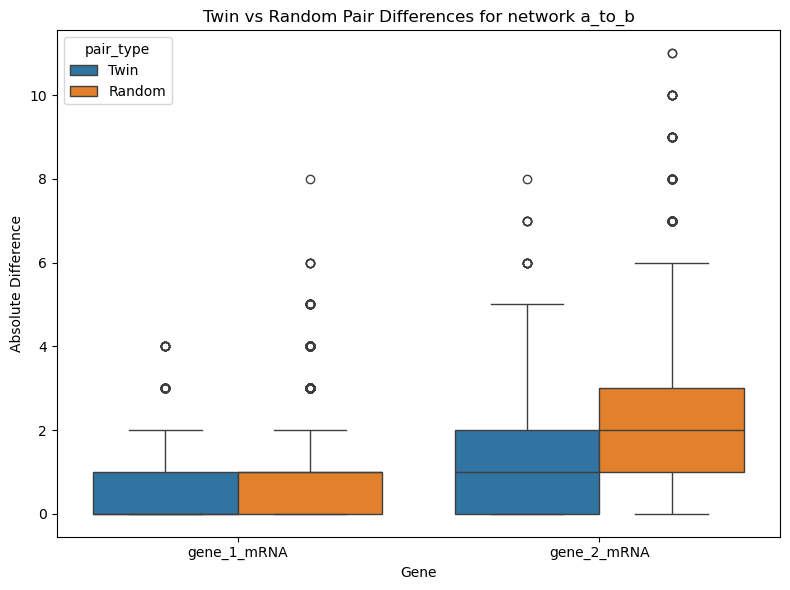


Effect Size Summary for a_and_b:
          Gene  MedianShift(Random-Twin)  MeanRatio(Random/Twin)  CliffsDelta  \
0  gene_1_mRNA                       1.0                2.021227     0.386741   
1  gene_2_mRNA                       1.0                2.059701     0.398157   

   MannWhitney_p  
0            0.0  
1            0.0  


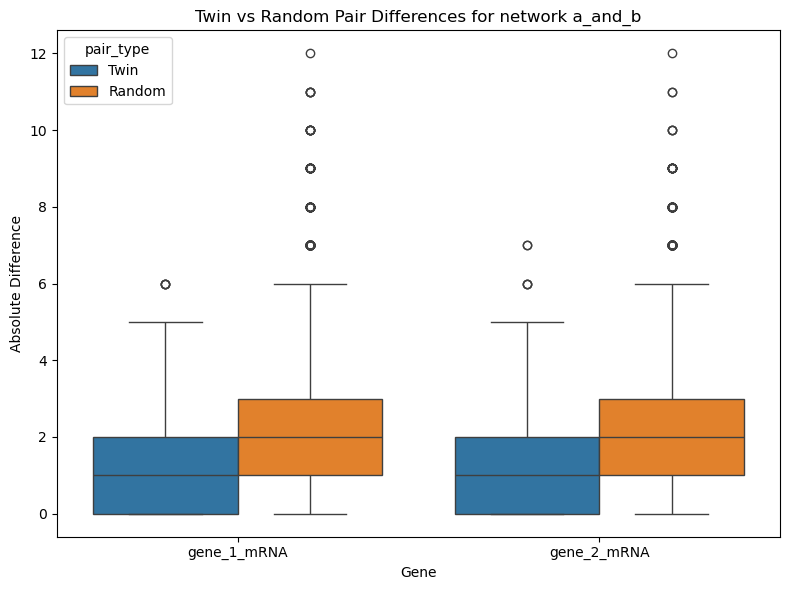


Effect Size Summary for mutual_reg:
          Gene  MedianShift(Random-Twin)  MeanRatio(Random/Twin)  CliffsDelta  \
0  gene_1_mRNA                       1.0                2.496839     0.359020   
1  gene_2_mRNA                       1.0                2.006793     0.397591   
2  gene_3_mRNA                       1.0                1.931942     0.373742   

   MannWhitney_p  
0  2.033724e-308  
1   0.000000e+00  
2  1.651432e-288  


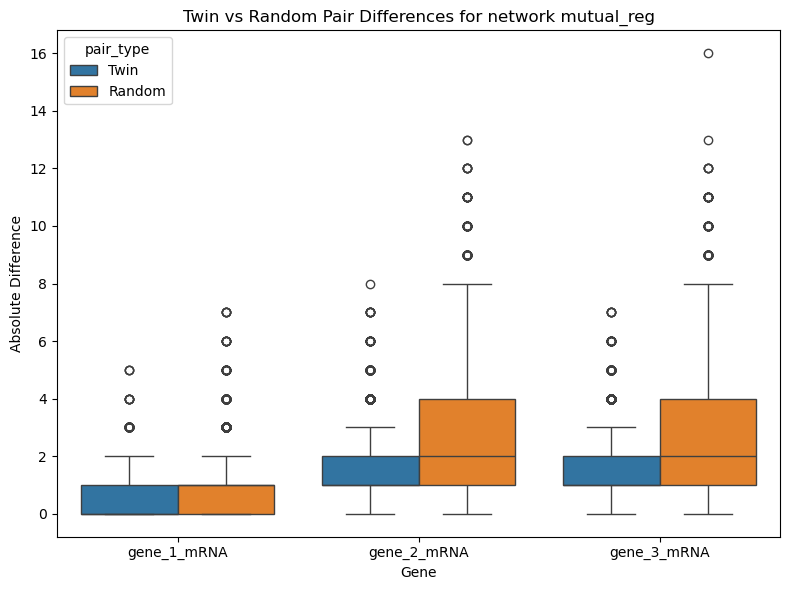


Effect Size Summary for fan_out:
          Gene  MedianShift(Random-Twin)  MeanRatio(Random/Twin)  CliffsDelta  \
0  gene_1_mRNA                       1.0                2.536313     0.370173   
1  gene_2_mRNA                       1.0                2.133769     0.418185   
2  gene_3_mRNA                       1.0                2.114921     0.412794   

   MannWhitney_p  
0            0.0  
1            0.0  
2            0.0  


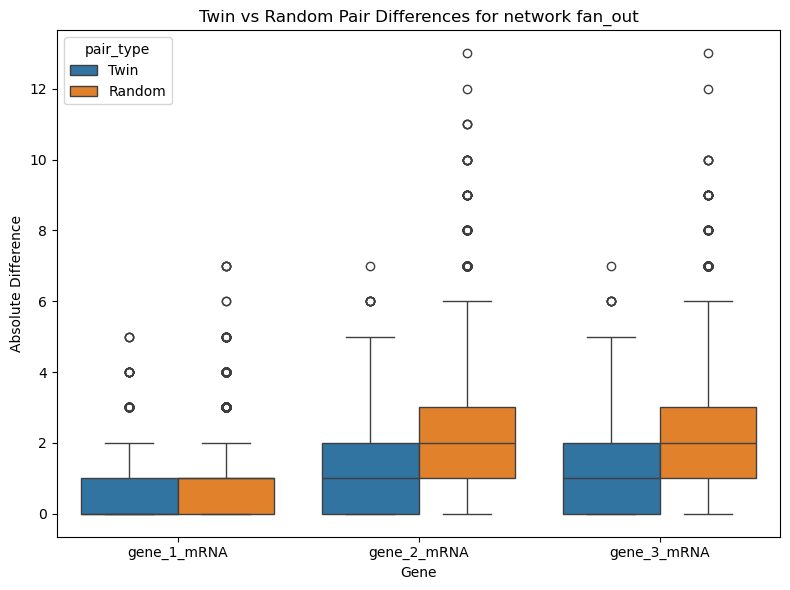


Effect Size Summary for fan_in:
          Gene  MedianShift(Random-Twin)  MeanRatio(Random/Twin)  CliffsDelta  \
0  gene_1_mRNA                       1.0                2.542040     0.371865   
1  gene_2_mRNA                       1.0                2.533701     0.367993   
2  gene_3_mRNA                       1.0                1.968217     0.380837   

   MannWhitney_p  
0   0.000000e+00  
1   0.000000e+00  
2  4.529413e-301  


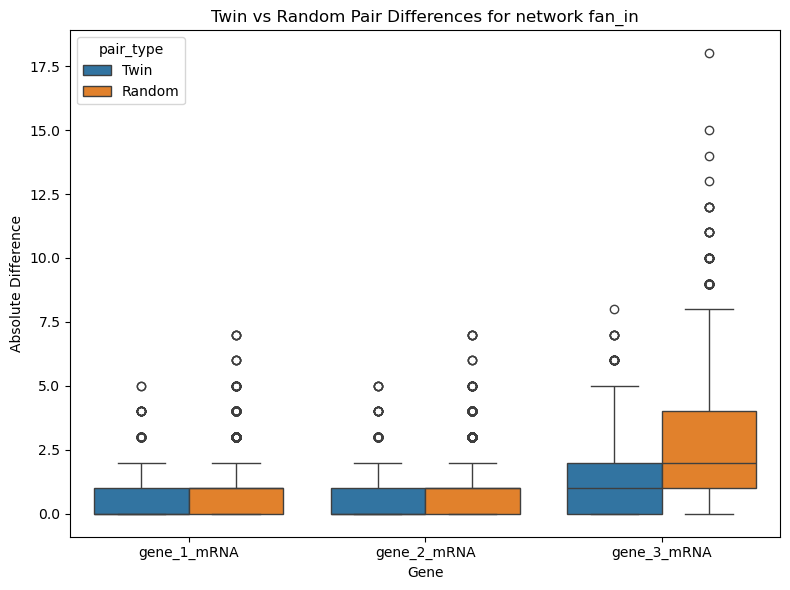


Effect Size Summary for feed_forward:
          Gene  MedianShift(Random-Twin)  MeanRatio(Random/Twin)  CliffsDelta  \
0  gene_1_mRNA                       1.0                2.495928     0.371236   
1  gene_2_mRNA                       1.0                2.137909     0.414186   
2  gene_3_mRNA                       1.0                2.060786     0.406744   

   MannWhitney_p  
0            0.0  
1            0.0  
2            0.0  


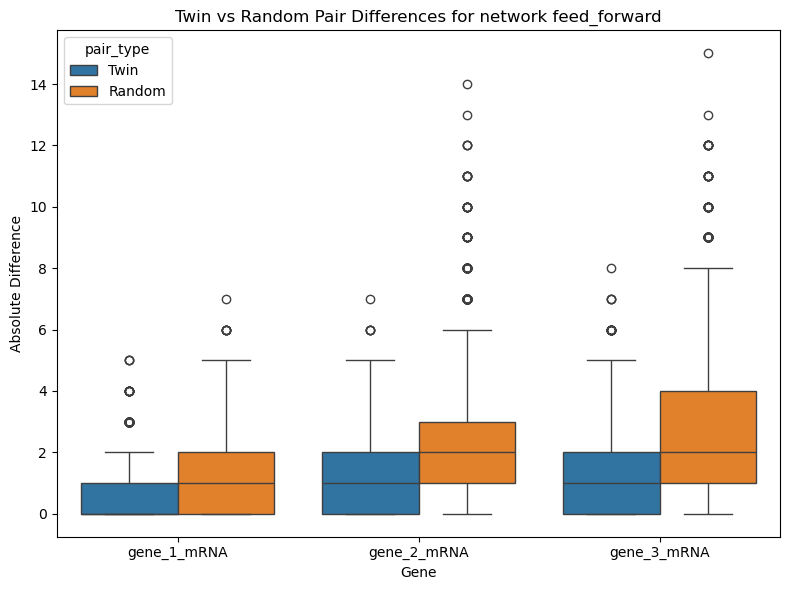

In [68]:
genes_3 = ["gene_1_protein", "gene_2_protein", "gene_3_protein"]
genes_2 = ["gene_1_protein", "gene_2_protein"]
genes_3 = ["gene_1_mRNA", "gene_2_mRNA", "gene_3_mRNA"]
genes_2 = ["gene_1_mRNA", "gene_2_mRNA"]
plot_gene_difference(a_to_b_t1, "a_to_b", genes_2)
plot_gene_difference(a_and_b_t1, "a_and_b", genes_2)
plot_gene_difference(mutual_reg_t1, "mutual_reg", genes_3)
plot_gene_difference(fan_out_t1, "fan_out", genes_3)
plot_gene_difference(fan_in_t1, "fan_in", genes_3)
plot_gene_difference(feed_forward_t1, "feed_forward", genes_3)

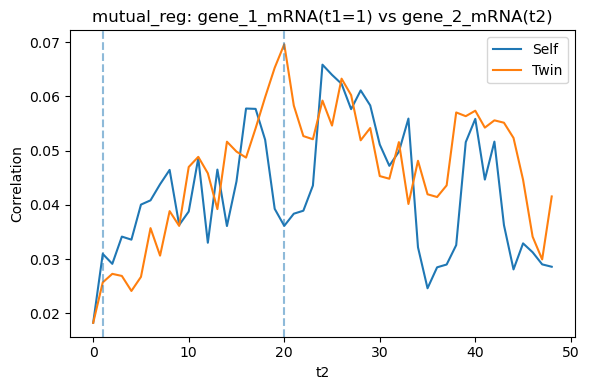

KeyboardInterrupt: 

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_self_vs_twin_crosscorr_fast(
    df,
    network,
    gene_X,
    gene_Y,
    t1,
    time_col="time_step",
    clone_col="clone_id",
    cell_col="cell_id"
):

    # -------------------------------------------------
    # Keep only needed columns
    # -------------------------------------------------
    df_sub = df[[clone_col, cell_col, time_col, gene_X, gene_Y]].copy()

    # -------------------------------------------------
    # Identify valid twin clones (exactly 2 cells)
    # -------------------------------------------------
    clone_sizes = df_sub.groupby(clone_col)[cell_col].nunique()
    valid_clones = clone_sizes[clone_sizes == 2].index
    df_sub = df_sub[df_sub[clone_col].isin(valid_clones)]

    # -------------------------------------------------
    # Assign twin index 0/1 within each clone
    # -------------------------------------------------
    df_sub["twin_index"] = (
        df_sub.groupby(clone_col)[cell_col]
              .transform(lambda x: pd.factorize(x)[0])
    )

    # -------------------------------------------------
    # Pivot into structured arrays
    # shape: (n_clones, 2, n_times)
    # -------------------------------------------------
    pivot_X = (
        df_sub.pivot_table(
            index=[clone_col, "twin_index"],
            columns=time_col,
            values=gene_X
        )
        .sort_index()
    )

    pivot_Y = (
        df_sub.pivot_table(
            index=[clone_col, "twin_index"],
            columns=time_col,
            values=gene_Y
        )
        .sort_index()
    )

    # Convert to numpy
    times = pivot_X.columns.values
    n_clones = len(valid_clones)

    X_array = pivot_X.to_numpy().reshape(n_clones, 2, -1)
    Y_array = pivot_Y.to_numpy().reshape(n_clones, 2, -1)

    # Find index of t1
    if t1 not in times:
        raise ValueError("t1 not in available time points")

    t1_idx = np.where(times == t1)[0][0]

    # -------------------------------------------------
    # Compute correlations
    # -------------------------------------------------
    corr_self = []
    corr_twin = []

    X_t1 = X_array[:, 0, t1_idx]   # use twin 0 as reference

    for t2_idx in range(len(times)):

        Y_self = Y_array[:, 0, t2_idx]
        Y_twin = Y_array[:, 1, t2_idx]

        if len(X_t1) > 3:
            corr_self.append(np.corrcoef(X_t1, Y_self)[0, 1])
            corr_twin.append(np.corrcoef(X_t1, Y_twin)[0, 1])
        else:
            corr_self.append(np.nan)
            corr_twin.append(np.nan)

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    plt.figure(figsize=(6,4))
    plt.plot(times, corr_self, label="Self")
    plt.plot(times, corr_twin, label="Twin")
    plt.axvline(t1, linestyle="--", alpha=0.5)
    plt.axvline(20, linestyle="--", alpha=0.5)
    plt.xlabel("t2")
    plt.ylabel("Correlation")
    plt.title(f"{network}: {gene_X}(t1={t1}) vs {gene_Y}(t2)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "time": times,
        "self_corr": corr_self,
        "twin_corr": corr_twin
    })

    
t1 = 1
gene_pairs = [['gene_1_mRNA', 'gene_2_mRNA'], ['gene_2_mRNA', 'gene_1_mRNA'], ['gene_2_mRNA', 'gene_3_mRNA'], ['gene_3_mRNA', 'gene_2_mRNA']]
for [ gene_X, gene_Y ] in gene_pairs:
    data = plot_self_vs_twin_crosscorr_fast(
        mutual_reg,
        "mutual_reg",
        gene_X,
        gene_Y,
        t1,
        time_col="time_step",
        clone_col="clone_id",
        cell_col="cell_id"
    )



# compare self to twin

In [137]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def compute_self_vs_twin_crosscorr_spearman(
    df,
    gene_X,
    gene_Y,
    t1,
    time_col="time_step",
    clone_col="clone_id",
    cell_col="cell_id"
):

    df_sub = df[[clone_col, cell_col, time_col, gene_X, gene_Y]].copy()

    clone_sizes = df_sub.groupby(clone_col)[cell_col].nunique()
    valid_clones = clone_sizes[clone_sizes == 2].index
    df_sub = df_sub[df_sub[clone_col].isin(valid_clones)]

    df_sub["twin_index"] = (
        df_sub.groupby(clone_col)[cell_col]
              .transform(lambda x: pd.factorize(x)[0])
    )

    pivot_X = (
        df_sub.pivot_table(
            index=[clone_col, "twin_index"],
            columns=time_col,
            values=gene_X
        )
        .sort_index()
    )

    pivot_Y = (
        df_sub.pivot_table(
            index=[clone_col, "twin_index"],
            columns=time_col,
            values=gene_Y
        )
        .sort_index()
    )

    times = pivot_X.columns.values
    n_clones = pivot_X.index.get_level_values(0).nunique()

    X_array = pivot_X.to_numpy().reshape(n_clones, 2, -1)
    Y_array = pivot_Y.to_numpy().reshape(n_clones, 2, -1)

    if t1 not in times:
        raise ValueError("t1 not in available time points")

    t1_idx = np.where(times == t1)[0][0]

    corr_self = []
    corr_twin = []

    X_t1 = X_array[:, 0, t1_idx]

    for t2_idx in range(len(times)):

        Y_self = Y_array[:, 0, t2_idx]
        Y_twin = Y_array[:, 1, t2_idx]

        # Remove NaNs pairwise
        mask_self = np.isfinite(X_t1) & np.isfinite(Y_self)
        mask_twin = np.isfinite(X_t1) & np.isfinite(Y_twin)

        if mask_self.sum() > 3:
            corr_self.append(
                spearmanr(X_t1[mask_self], Y_self[mask_self]).correlation
            )
        else:
            corr_self.append(np.nan)

        if mask_twin.sum() > 3:
            corr_twin.append(
                spearmanr(X_t1[mask_twin], Y_twin[mask_twin]).correlation
            )
        else:
            corr_twin.append(np.nan)

    return times, np.array(corr_self), np.array(corr_twin)


import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_replicates(
    file_pattern,
    t1,
    network,
    gene_Z="gene_1_protein",
    gene_X="gene_2_protein",
    gene_Y="gene_3_protein"
):

    pairs = [
        (gene_Z, gene_X),
        (gene_Z, gene_Y),
        (gene_X, gene_Y),
        (gene_Y, gene_X),
    ]

    files = sorted(glob.glob(file_pattern))[:10]
    print(f"Found {len(files)} replicates")

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

    axes = axes.flatten()

    for ax, (gX, gY) in zip(axes, pairs):

        all_self = []
        all_twin = []

        for f in files:
            df = pd.read_csv(f)

            times, corr_self, corr_twin = compute_self_vs_twin_crosscorr_fast(
                df,
                gX,
                gY,
                t1
            )

            all_self.append(corr_self)
            all_twin.append(corr_twin)

        all_self = np.vstack(all_self)
        all_twin = np.vstack(all_twin)

        mean_self = np.nanmean(all_self, axis=0)
        mean_twin = np.nanmean(all_twin, axis=0)

        sem_self = np.nanstd(all_self, axis=0) / np.sqrt(all_self.shape[0])
        sem_twin = np.nanstd(all_twin, axis=0) / np.sqrt(all_twin.shape[0])

        ax.plot(times, mean_self, label="Self")
        ax.fill_between(times, mean_self-sem_self, mean_self+sem_self, alpha=0.3)

        ax.plot(times, mean_twin, label="Twin")
        ax.fill_between(times, mean_twin-sem_twin, mean_twin+sem_twin, alpha=0.3)

        ax.axvline(t1, linestyle="--", alpha=0.5)
        ax.set_title(f"{gX}(t1) → {gY}(t2)")
        ax.set_xlabel("t2")
        ax.set_ylabel("Correlation")

    axes[0].legend()
    plt.suptitle(f"{network} — Replicate Averaged Cross-Correlation")
    plt.tight_layout()
    plt.show()


In [180]:
def plot_replicates_twin_only(
    file_pattern,
    t1,
    network,
    gene_Z="gene_1_protein",
    gene_X="gene_2_protein",
    gene_Y="gene_3_protein"
):

    pairs = [
        (gene_Z, gene_X),
        (gene_Z, gene_Y),
        (gene_X, gene_Y),
        (gene_Y, gene_X),
        (gene_X, gene_X),
        (gene_Y, gene_Y)
    ]

    gene_name = {"1": "Z", "2": "X", "3": "Y"}

    files = sorted(glob.glob(file_pattern))[:10]
    print(f"Found {len(files)} replicates")

    # Base colors
    color_map = {
        "X -> Y": "#ff7f0e",   # orange
        "Z -> X": "#1f77b4",   # blue
        "Y -> X": "#2ca02c",   # green
        "Z -> Y": "#ffbf00",   # gold
        "X -> X": "#9467bd",   # purple
        # "Y -> Y": "black",   # cyan
    }

    # Style overrides for self edges
    style_map = {
        "X -> X": dict(linestyle="-",  linewidth=3.0),
        "Y -> Y": dict(linestyle="--", linewidth=3.0),
    }

    plt.figure(figsize=(7, 5))

    for (gX, gY) in pairs:

        all_twin = []

        for f in files:
            df = pd.read_csv(f)

            times, _, corr_twin = compute_self_vs_twin_crosscorr_spearman(
                df,
                gX,
                gY,
                t1
            )

            all_twin.append(corr_twin)

        all_twin = np.vstack(all_twin)

        mean_twin = np.nanmean(all_twin, axis=0)
        sem_twin = np.nanstd(all_twin, axis=0) / np.sqrt(all_twin.shape[0])

        g1 = gX.split('_')[1]
        g2 = gY.split('_')[1]
        label = f"{gene_name[g1]} -> {gene_name[g2]}"

        color = color_map[label]

        # Apply style override if self-edge
        style = style_map.get(label, dict(linestyle="-", linewidth=2.0))

        plt.plot(
            times,
            mean_twin,
            label=label,
            color=color,
            alpha=0.95,
            **style
        )

        # plt.fill_between(
        #     times,
        #     mean_twin - sem_twin,
        #     mean_twin + sem_twin,
        #     color=color,
        #     alpha=0.15
        # )

    plt.axvline(t1, linestyle="--", alpha=0.5)

    plt.xlabel("t2")
    plt.ylabel("Spearman correlation (Twin)")
    plt.title(f"{network} — Twin Cross-Correlation")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


Found 10 replicates


KeyError: 'Y -> Y'

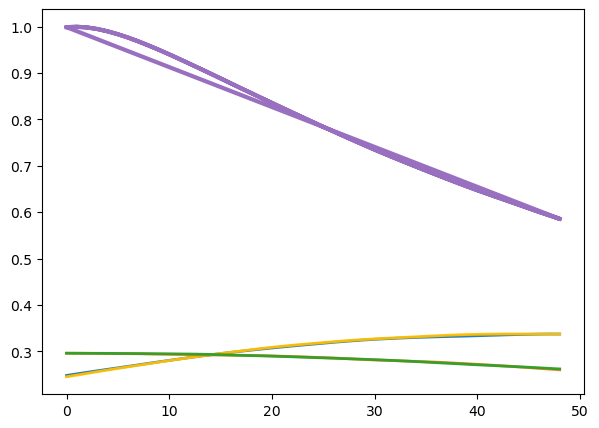

In [181]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/mutual_regulation/df_rows_0_0_0_*_ncells_6000_mutual_regulation_k_add_6_*.csv"
t1 = 1
plot_replicates_twin_only(file_pattern, t1, "Regulated mutual Protein")

Found 10 replicates


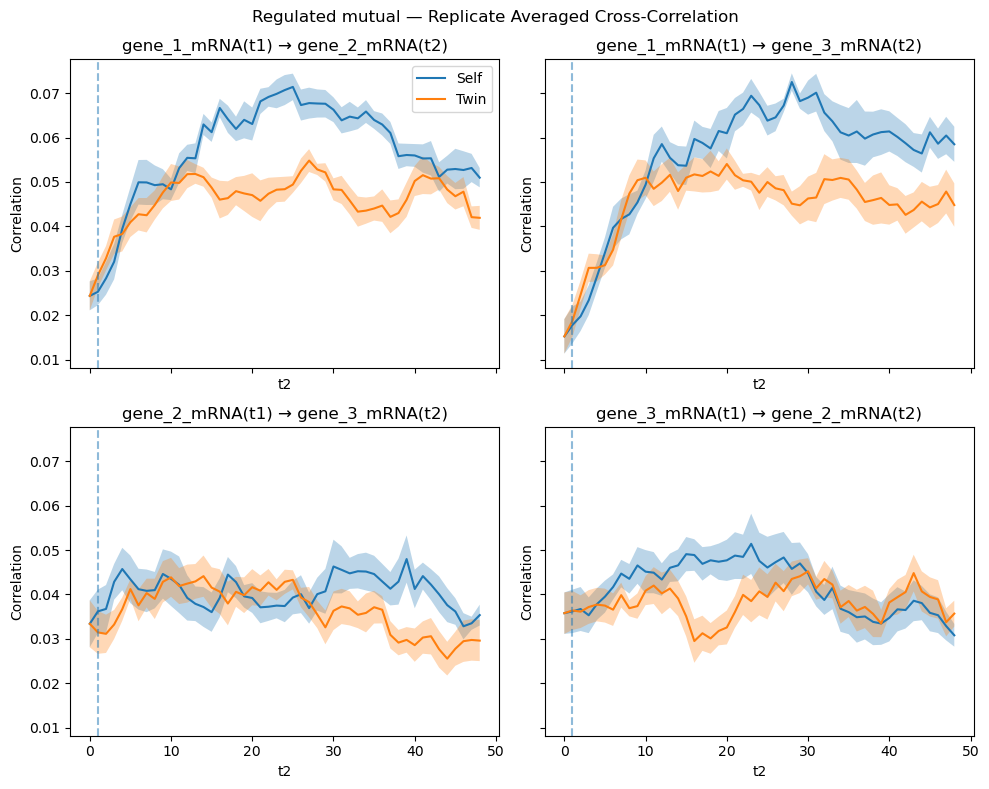

In [86]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/mutual_regulation/df_rows_0_0_0_*_ncells_6000_mutual_regulation_k_add_6_*.csv"
t1 = 1
plot_replicates(file_pattern, t1, "Regulated mutual")

Found 10 replicates


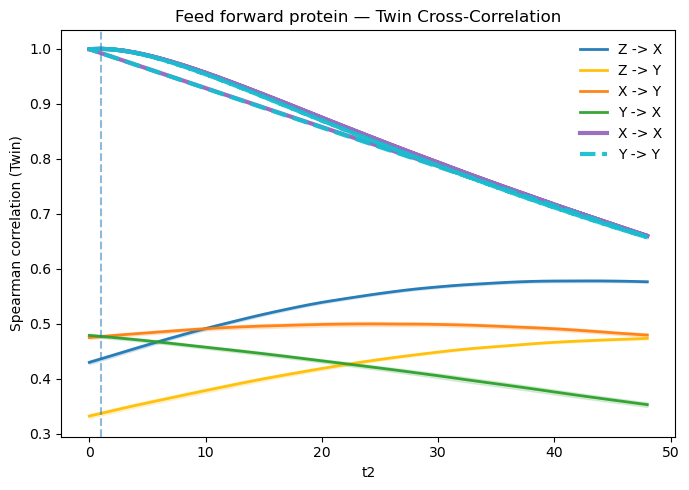

In [134]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/feed_forward/df_rows_0_0_0_*_ncells_6000_feed_forward_k_add_6_*.csv"
t1 = 1
plot_replicates_twin_only(file_pattern, t1, "Feed forward protein")

Found 10 replicates


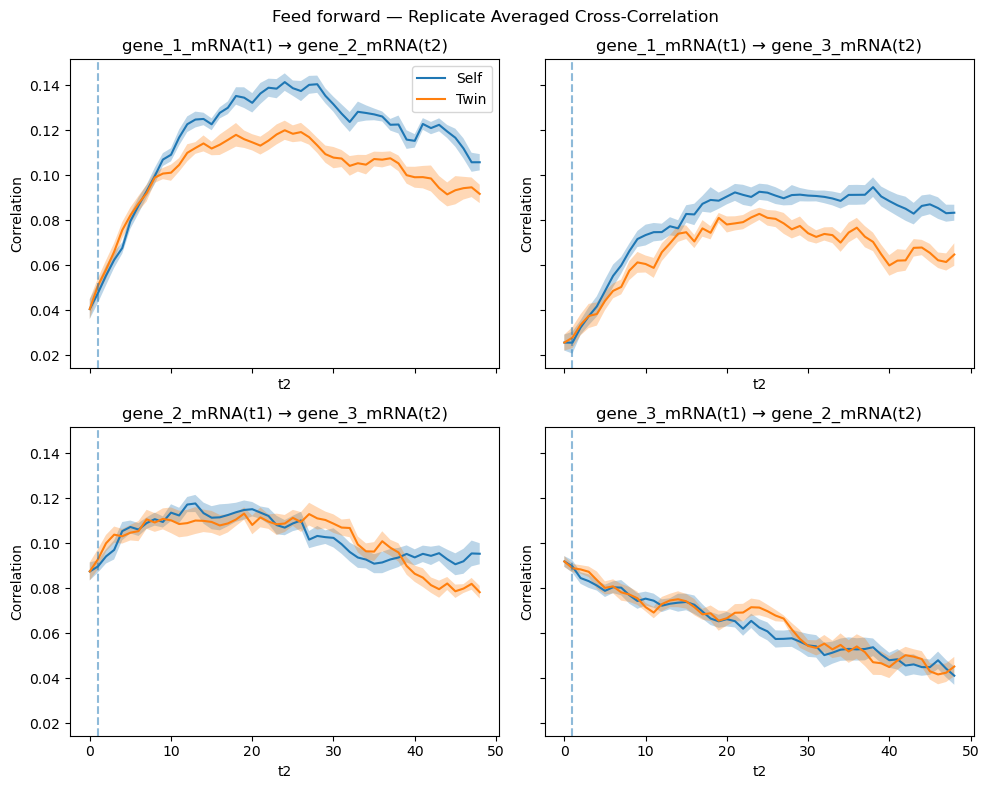

In [87]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/feed_forward/df_rows_0_0_0_*_ncells_6000_feed_forward_k_add_6_*.csv"
t1 = 1
plot_replicates(file_pattern, t1, "Feed forward")

Found 10 replicates


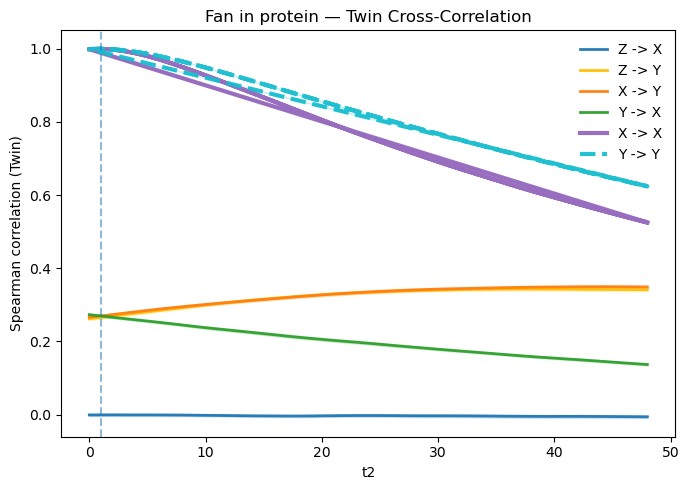

In [135]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/fan_in/df_rows_0_0_0_*_ncells_6000_fan_in_k_add_6_*.csv"
t1 = 1
plot_replicates_twin_only(file_pattern, t1, "Fan in protein")

Found 10 replicates


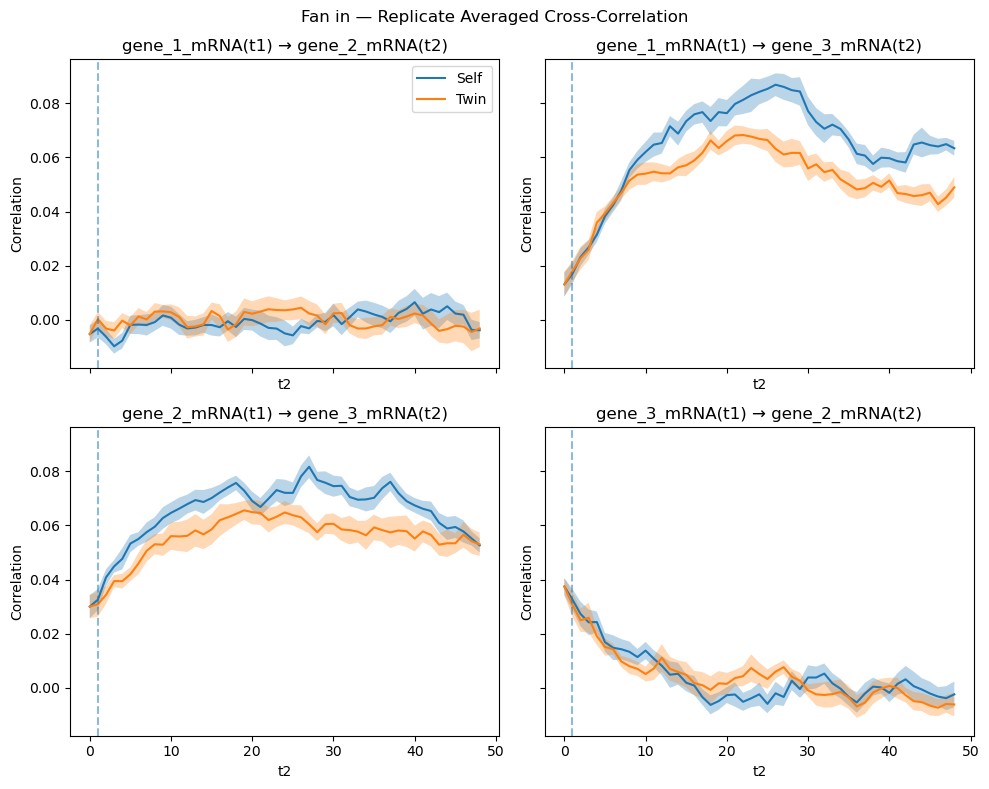

In [88]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/fan_in/df_rows_0_0_0_*_ncells_6000_fan_in_k_add_6_*.csv"
t1 = 1
plot_replicates(file_pattern, t1, "Fan in")

Found 10 replicates


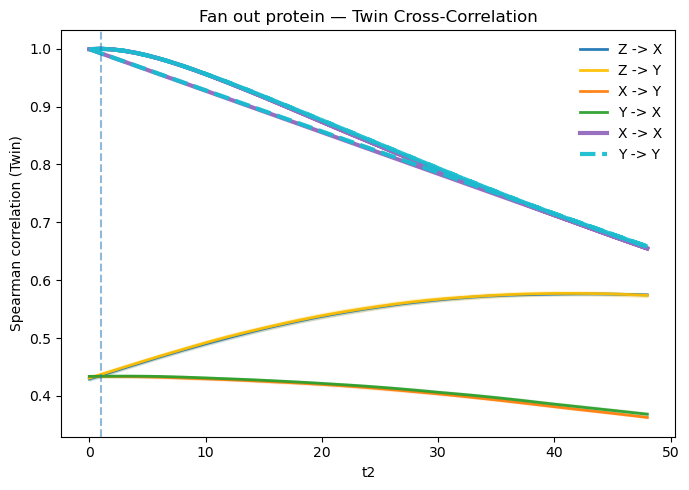

In [136]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/df_rows_0_0_0_*_ncells_6000_Fan_out_additive_*.csv"
t1 = 1
plot_replicates_twin_only(file_pattern, t1, "Fan out protein")


Found 10 replicates


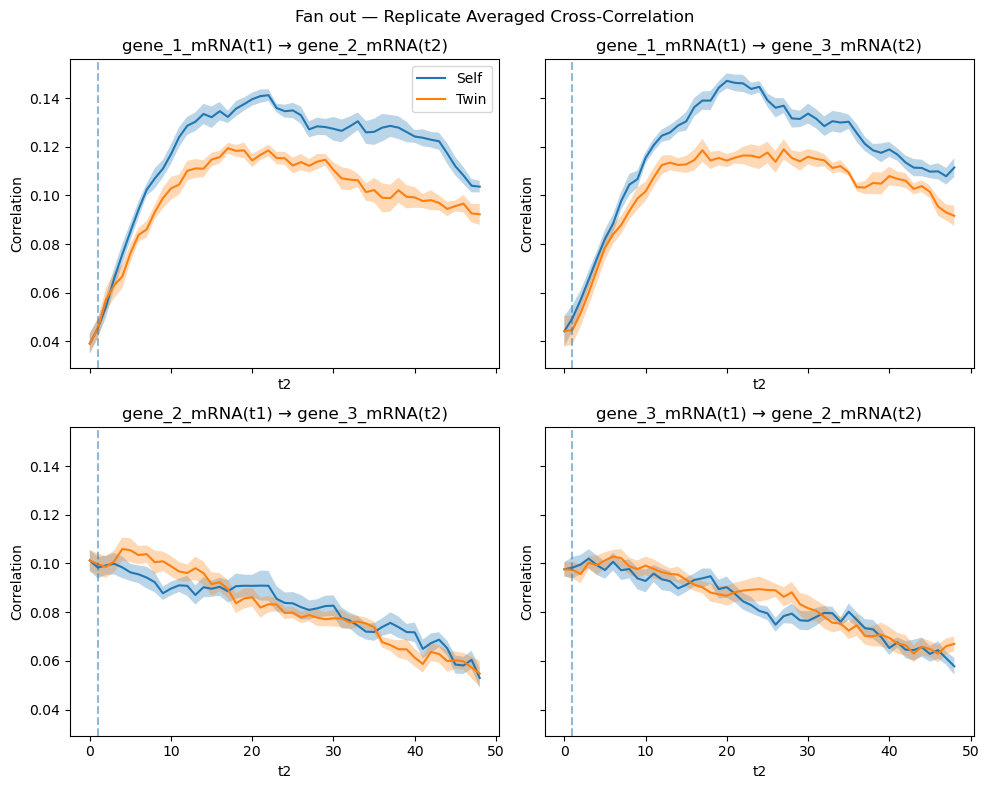

In [89]:
file_pattern = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/df_rows_0_0_0_*_ncells_6000_Fan_out_additive_*.csv"
t1 = 1
plot_replicates(file_pattern, t1, "Fan out")


<Figure size 1200x600 with 0 Axes>

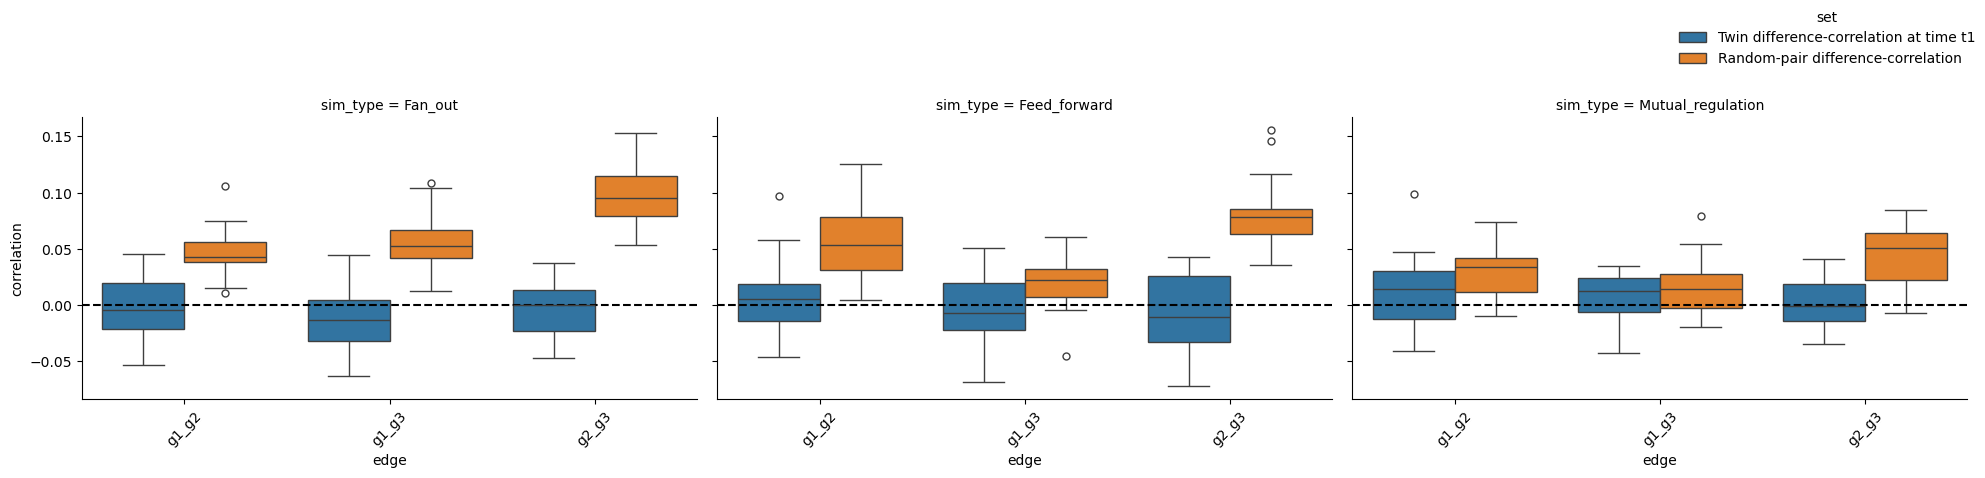

In [172]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_A = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_23012026/twin_t1_matrix_results.csv")
df_B = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_23012026/random_matrix_results.csv")

df_A["set"] = "Twin difference-correlation at time t1"
df_B["set"] = "Random-pair difference-correlation"

df = pd.concat([df_A, df_B], ignore_index=True)

edge_cols = [
    "g1_g1","g1_g2","g1_g3",
    "g2_g1","g2_g2","g2_g3",
    "g3_g1","g3_g2","g3_g3"
]

df_long = df.melt(
    id_vars=["sim_type", "rep_id", "analysis_key", "set"],
    value_vars=edge_cols,
    var_name="edge",
    value_name="correlation"
)
df_long = df_long[~df_long["edge"].isin(["g1_g1","g2_g2","g3_g3", "g3_g1", "g2_g1", "g3_g2"])]
plt.figure(figsize=(12, 6))

g = sns.catplot(
    data=df_long,
    x="edge",
    y="correlation",
    hue="set",
    col="sim_type",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1.4,
    sharey=True
)

g._legend.set_bbox_to_anchor((1, 1.1))
g._legend.set_frame_on(False)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0,linestyle = "--", color = "black")

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

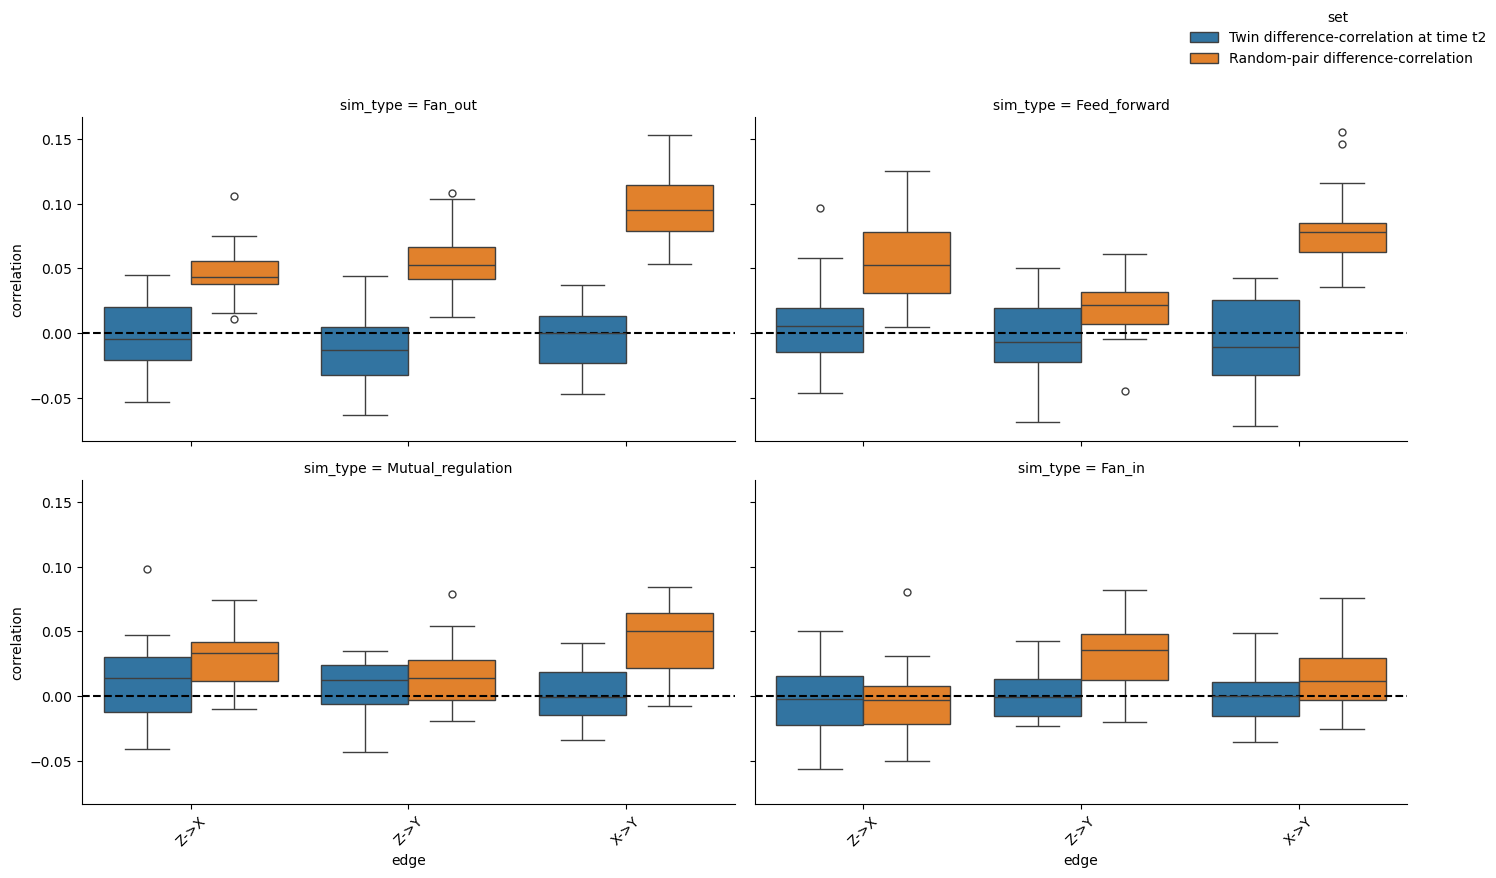

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_A = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_23012026/twin_t1_matrix_results.csv")
df_C = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_19022026/twin_t1_matrix_results.csv")
df_B = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_23012026/random_matrix_results.csv")
df_D = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_19022026/random_matrix_results.csv")

df_A["set"] = "Twin difference-correlation at time t2"
df_B["set"] = "Random-pair difference-correlation"
df_C["set"] = "Twin difference-correlation at time t2"
df_D["set"] = "Random-pair difference-correlation"
df = pd.concat([df_A, df_B, df_C, df_D], ignore_index=True)

edge_cols = [
    "g1_g1","g1_g2","g1_g3",
    "g2_g1","g2_g2","g2_g3",
    "g3_g1","g3_g2","g3_g3"
]

df_long = df.melt(
    id_vars=["sim_type", "rep_id", "analysis_key", "set"],
    value_vars=edge_cols,
    var_name="edge",
    value_name="correlation"
)
df_long = df_long[~df_long["edge"].isin(["g1_g1","g2_g2","g3_g3", "g3_g1", "g2_g1", "g3_g2"])]

# Map gene labels
gene_map = {
    "g1": "Z",
    "g2": "X",
    "g3": "Y"
}

def rename_edge(edge):
    gA, gB = edge.split("_")
    return f"{gene_map[gA]}->{gene_map[gB]}"

df_long["edge"] = df_long["edge"].apply(rename_edge)
plt.figure(figsize=(12, 6))

g = sns.catplot(
    data=df_long,
    x="edge",
    y="correlation",
    hue="set",
    col="sim_type",
    kind="box",
    col_wrap=2,
    height=4,
    aspect=1.4,
    sharey=True
)

g._legend.set_bbox_to_anchor((1.05, 1.05))
g._legend.set_frame_on(False)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0,linestyle = "--", color = "black")

plt.tight_layout()
plt.show()

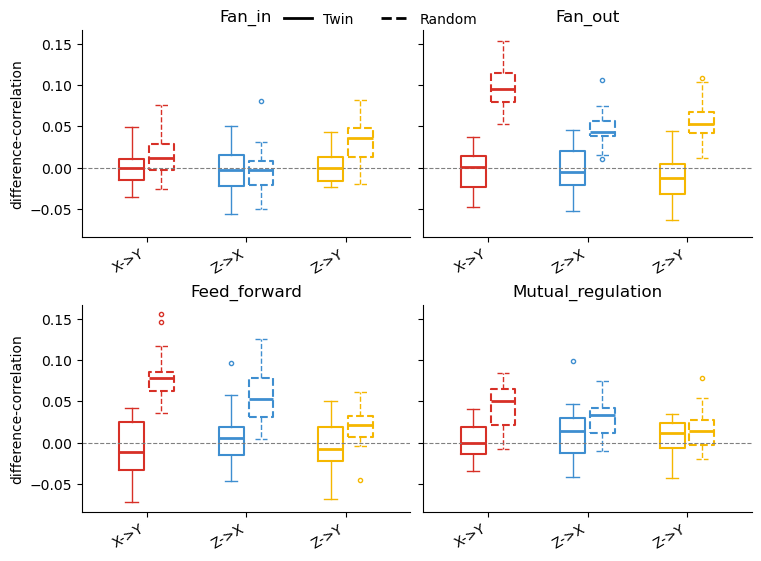

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Edge colors (match previous style)
EDGE_COLORS = {
    "Z->X": "#3E8ED0",
    "Z->Y": "#F5B700",
    "X->Y": "#D73027",
    "Y->X": "#00A676",
}

sim_types = sorted(df_long["sim_type"].unique())
edges = sorted(df_long["edge"].unique())

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.5, 5.5),
    sharey=True,
    constrained_layout=True
)

for ax, sim in zip(axes.ravel(), sim_types):

    df_sub = df_long[df_long["sim_type"] == sim]
    positions = np.arange(1, len(edges) + 1)

    for i, edge in enumerate(edges):

        color = EDGE_COLORS.get(edge, "#333333")

        # Twin (solid)
        twin_vals = df_sub[
            (df_sub["edge"] == edge) &
            (df_sub["set"] == "Twin difference-correlation at time t2")
        ]["correlation"].dropna().values

        ax.boxplot(
            twin_vals,
            positions=[positions[i] - 0.15],
            widths=0.25,
            patch_artist=False,
            medianprops=dict(color=color, linewidth=2),
            boxprops=dict(color=color, linewidth=1.5, linestyle="-"),
            whiskerprops=dict(color=color, linestyle="-"),
            capprops=dict(color=color, linestyle="-"),
            flierprops=dict(
                marker="o",
                markerfacecolor="none",
                markeredgecolor=color,
                markersize=3
            ),
        )

        # Random (dashed)
        rand_vals = df_sub[
            (df_sub["edge"] == edge) &
            (df_sub["set"] == "Random-pair difference-correlation")
        ]["correlation"].dropna().values

        ax.boxplot(
            rand_vals,
            positions=[positions[i] + 0.15],
            widths=0.25,
            patch_artist=False,
            medianprops=dict(color=color, linewidth=2),
            boxprops=dict(color=color, linewidth=1.5, linestyle="--"),
            whiskerprops=dict(color=color, linestyle="--"),
            capprops=dict(color=color, linestyle="--"),
            flierprops=dict(
                marker="o",
                markerfacecolor="none",
                markeredgecolor=color,
                markersize=3
            ),
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(edges, rotation=30, ha="right")
    ax.set_title(sim)

    ax.axhline(0, linestyle="--", color="gray", linewidth=0.8)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# Y-label only left column
axes[0, 0].set_ylabel("difference-correlation")
axes[1, 0].set_ylabel("difference-correlation")

# Legend (solid vs dashed)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="black", lw=2, linestyle="-",
           label="Twin"),
    Line2D([0], [0], color="black", lw=2, linestyle="--",
           label="Random"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    frameon=False
)

plt.show()

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from numpy.random import default_rng
from scipy.stats import pearsonr
from matplotlib.ticker import MultipleLocator
from scipy.linalg import solve_continuous_lyapunov, cholesky
import matplotlib.font_manager as fm
import os

# ============================================================
# Font registration + global rcParams (LaTeX-like style)
# ============================================================
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
# Register Arial + CM math fonts from your home directory
font_files = [
    f"{path_to_code_repo}/fonts/Arial.ttf",
    f"{path_to_code_repo}/fonts/Arial Bold.ttf",
    f"{path_to_code_repo}/fonts/Arial Italic.ttf",
]

for fp in font_files:
    try:
        fm.fontManager.addfont(fp)
        print(f"✔ Registered font: {fp}")
    except Exception as e:
        print(f"⚠️  Could not register font {fp}: {e}")

# Global plotting style
# Global Matplotlib style (match second script)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = "none"

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family']     = "sans-serif"
plt.rcParams['mathtext.fontset'] = "cm"

plt.rcParams['axes.labelsize']  = 12
plt.rcParams['axes.titlesize']  = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 12

plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid']  = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# A bit of your usual styling
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

✔ Registered font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial.ttf
✔ Registered font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Bold.ttf
✔ Registered font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Italic.ttf


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


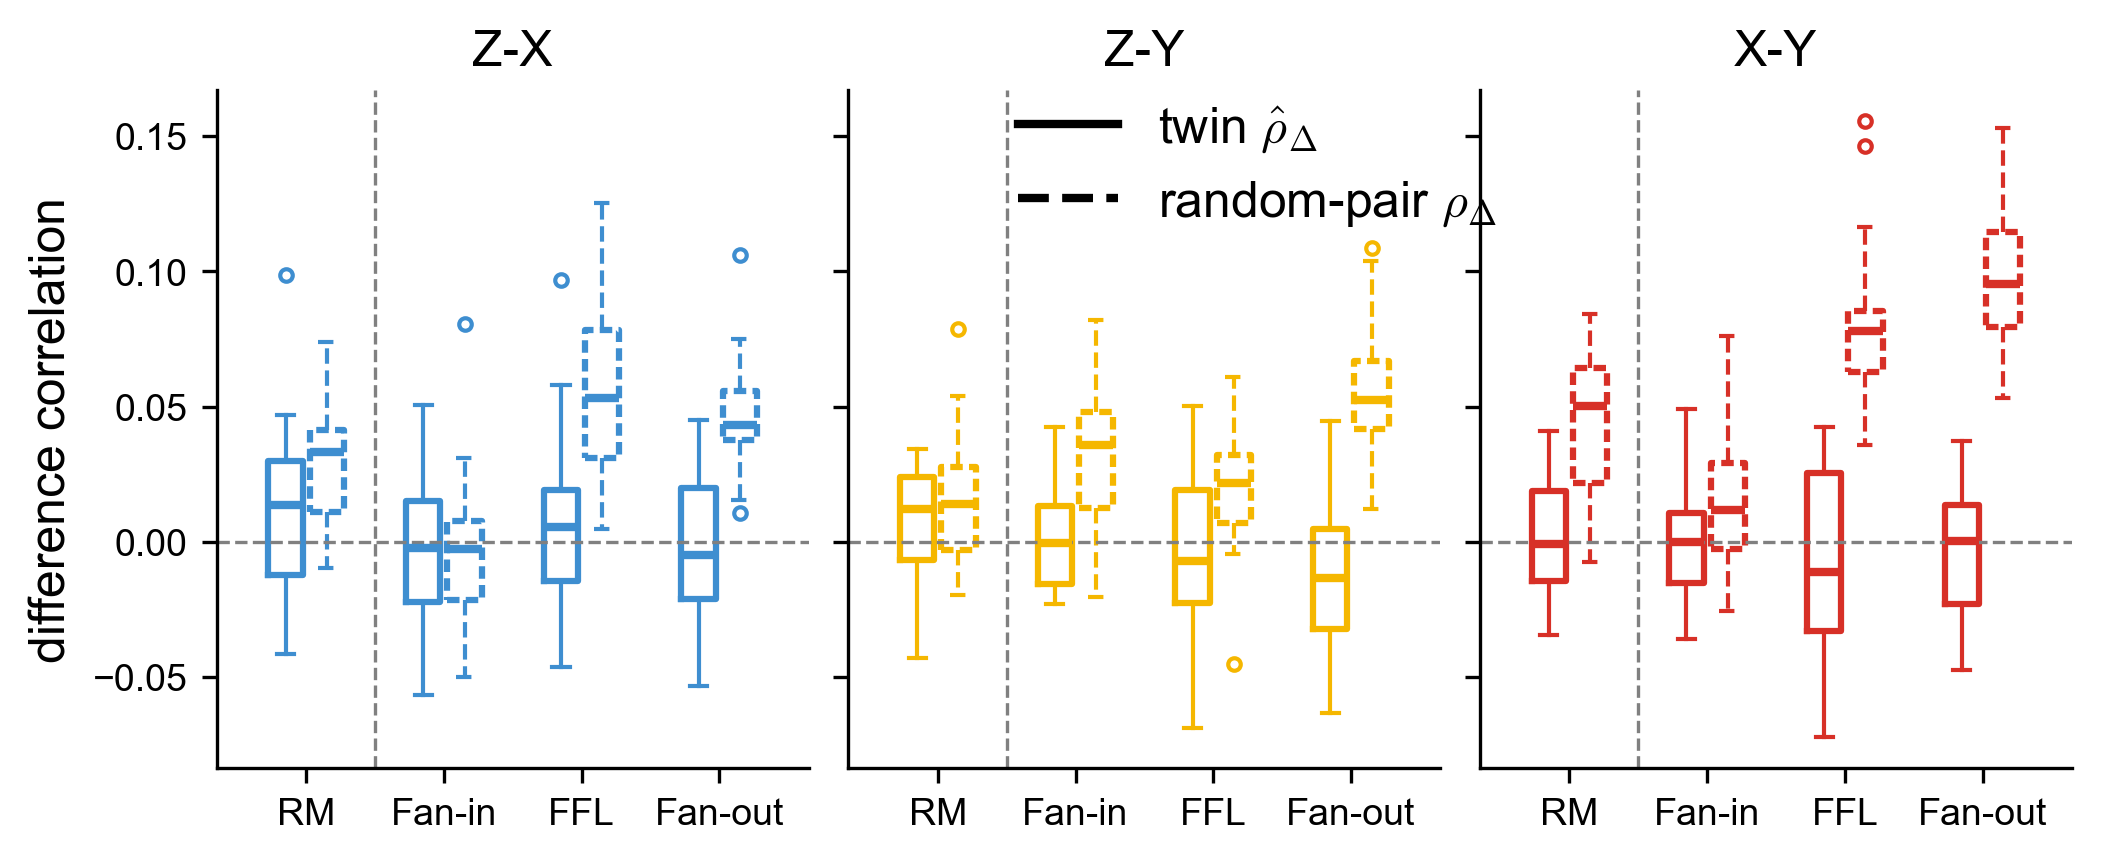

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Fixed motif order
motif_order = ["mutual_regulation", "fan_in", "feed_forward", "fan_out"]

MOTIF_LABELS = {
    "mutual_regulation": "RM",
    "fan_in": "Fan-in",
    "feed_forward": "FFL",
    "fan_out": "Fan-out",
}

edges = ["Z->X", "Z->Y", "X->Y"]
edge_labels = {"Z->X": "Z-X", "Z->Y":"Z-Y", "X->Y":"X-Y"}

EDGE_COLORS = {
    "Z->X": "#3E8ED0",
    "Z->Y": "#F5B700",
    "X->Y": "#D73027",
    "Y->X": "#00A676",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(6.89, 3*6.89/7.5),
    sharey=True,
    constrained_layout=True
)

for ax, edge in zip(axes.ravel(), edges):

    df_edge = df_long[df_long["edge"] == edge]
    color = EDGE_COLORS.get(edge, "#333333")

    positions = np.arange(1, len(motif_order) + 1)

    for i, motif in enumerate(motif_order):

        # Twin
        twin_vals = df_edge[
            ((df_edge["analysis_key"].str.contains(motif, case=False, regex=False))) &
            (df_edge["set"] == "Twin difference-correlation at time t2")
        ]["correlation"].dropna().values

        ax.boxplot(
            twin_vals,
            positions=[positions[i] - 0.15],
            widths=0.25,
            patch_artist=False,
            medianprops=dict(color=color, linewidth=2),
            boxprops=dict(color=color, linewidth=1.5, linestyle="-"),
            whiskerprops=dict(color=color, linestyle="-"),
            capprops=dict(color=color, linestyle="-"),
            flierprops=dict(marker="o",
                            markerfacecolor="none",
                            markeredgecolor=color,
                            markersize=3),
        )

        # Random
        rand_vals = df_edge[
            ((df_edge["analysis_key"].str.contains(motif, case=False, regex=False))) &
            (df_edge["set"] == "Random-pair difference-correlation")
        ]["correlation"].dropna().values
        ax.boxplot(
            rand_vals,
            positions=[positions[i] + 0.15],
            widths=0.25,
            patch_artist=False,
            medianprops=dict(color=color, linewidth=2),
            boxprops=dict(color=color,
              linewidth=1.5,
              linestyle=(0, (2, 1))),
            whiskerprops=dict(color=color, linestyle="--"),
            capprops=dict(color=color, linestyle="--"),
            flierprops=dict(marker="o",
                            markerfacecolor="none",
                            markeredgecolor=color,
                            markersize=3),
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [MOTIF_LABELS[m] for m in motif_order],
        rotation=0,
        ha="center"
    )

    ax.set_title(edge_labels[edge])
    ax.axhline(0, linestyle="--", color="gray", linewidth=0.8)
    ax.axvline(1.5, linestyle="--", color="gray", linewidth=0.8)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# Y-label left column only
axes[0].set_ylabel("difference correlation")
# axes[1, 0].set_ylabel("difference-correlation")

# Legend
legend_elements = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label=r"twin $\hat{\rho}_\Delta$"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label=r"random-pair $\rho_{\Delta}$"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.6, 0.95),  # adjust second value
    ncol=1,
    frameon=False
)
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4_motifs/"
plt.savefig(f"{path_to_plots}/z_Score.pdf", 
           format="pdf", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/z_Score.svg", 
           format="svg", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/z_Score.png", 
           format="png", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.show()